# Sentiment & Emotion Analysis Pipeline

Applies two pre-trained HuggingFace models to the top-5 most helpful reviews per product:
- **Sentiment:** `cardiffnlp/twitter-roberta-base-sentiment-latest` (positive / neutral / negative)
- **Emotion:** `j-hartmann/emotion-english-distilroberta-base` (joy, anger, sadness, fear, disgust, surprise, neutral)

Models are used for inference only — no training performed.

# Step 1 — Dependencies + Notebook Skeleton
## Imports

In [44]:
import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from pathlib import Path

## Device setup

In [45]:
device = 0 if torch.cuda.is_available() else -1
device_name = "GPU (cuda:0)" if device == 0 else "CPU"
print(f"Running inference on: {device_name}")

Running inference on: GPU (cuda:0)


## Data availability check

In [46]:
DATA_PATH = Path("../data/processed/amazon_reviews_s10.parquet")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run:\n  git lfs install\n  git lfs pull"
    )

file_size_mb = DATA_PATH.stat().st_size / (1024 ** 2)
if file_size_mb < 1:
    raise RuntimeError(
        f"{DATA_PATH} is only {file_size_mb:.1f} MB — likely a Git LFS pointer, not the actual file.\n"
        "Run:\n  git lfs install\n  git lfs pull"
    )

print(f"Data file OK: {file_size_mb:.0f} MB")

Data file OK: 288 MB


## Load data

In [47]:
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} reviews | {df['parent_asin'].nunique():,} products")
df.head(3)

Loaded 846,757 reviews | 204,998 products


,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio,images,combined_text,is_helpful,helpful_vote,parent_asin
0,5,439,5.1744,0,9163,1,2.079442,2,0,5,27,0.065534,[],"Incredibly rigid and strong [SEP] We have a 60” umbrella attached to a Vision5 flash hanging on this stand, and it’s solid as a rock! It rolls so smoothly and there are no tips! Trips are minima...",0,1,B07RHQJT1V
1,1,1600,5.1974,0,5207,1,2.397895,2,0,0,14,0.008827,[],"Don't Buy This [SEP] This is one of the worst electronic products I own for two reasons. I had the old Creative Zen player and loved it. It was fast, stored thousands of songs, and was easy to u...",1,4,B003D78O1Y
2,2,122,7.1111,0,7799,1,2.639057,1,0,0,9,0.079646,[],Two Stars [SEP] This actually started rusting and prohibited the open/close capability after bringing in/near water a few times.,0,1,B072FVHDSB


## Filter: top-5 per product

In [48]:
df_top5 = (
    df
    .sort_values(["helpful_vote", "review_length"], ascending=[False, False])
    .groupby("parent_asin", as_index=False)
    .head(5)
    .reset_index(drop=True)
)
print(f"After filtering: {len(df_top5):,} reviews | {df_top5['parent_asin'].nunique():,} products")

After filtering: 504,578 reviews | 204,998 products


Sampling Considerations

!!!!!!!!add Sana's markdown here!!!!!!!!!!!!!!!!!!!!!!!!!!!

## Load sentiment model

In [49]:
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    device=device,
    top_k=None,  # return all 3 class scores
)
print(f"Sentiment model ready: {SENTIMENT_MODEL}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11824.39it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment model ready: cardiffnlp/twitter-roberta-base-sentiment-latest


## Load emotion model

In [50]:
EMOTION_MODEL = "j-hartmann/emotion-english-distilroberta-base"

emotion_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    device=device,
    top_k=None,  # return all 7 class scores
)
print(f"Emotion model ready: {EMOTION_MODEL}")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 26390.34it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Emotion model ready: j-hartmann/emotion-english-distilroberta-base


## Smoke test on 100 rows

In [51]:
SAMPLE_SIZE = 100

sample_texts = df_top5["combined_text"].head(SAMPLE_SIZE).tolist()

sentiment_results = sentiment_pipe(sample_texts, truncation=True, max_length=512, batch_size=16)
emotion_results   = emotion_pipe(sample_texts,   truncation=True, max_length=512, batch_size=16)

print(f"Inference complete on {SAMPLE_SIZE} reviews.")
print("\nSample sentiment output (first review):")
print(sentiment_results[0])
print("\nSample emotion output (first review):")
print(emotion_results[0])

Inference complete on 100 reviews.

Sample sentiment output (first review):
[{'label': 'positive', 'score': 0.9556756019592285}, {'label': 'neutral', 'score': 0.03685436397790909}, {'label': 'negative', 'score': 0.007470050826668739}]

Sample emotion output (first review):
[{'label': 'neutral', 'score': 0.48453643918037415}, {'label': 'anger', 'score': 0.15898197889328003}, {'label': 'disgust', 'score': 0.11176056414842606}, {'label': 'surprise', 'score': 0.10441351681947708}, {'label': 'sadness', 'score': 0.07319239526987076}, {'label': 'joy', 'score': 0.04509754851460457}, {'label': 'fear', 'score': 0.02201748453080654}]


In [52]:
print("CUDA available:", torch.cuda.is_available())
print("Device used:", device)

CUDA available: True
Device used: 0


## Inference configuration

In [53]:
# Set to an integer (e.g. 10_000) to limit rows for CPU testing.
# Set to None to run on the full filtered dataset (recommended on GPU).
MAX_REVIEWS = 10_000

BATCH_SIZE = 32  # increase to 64 or 128 on GPU
OUTPUT_PATH = Path("../data/processed/sentiment_emotion_results.parquet")

df_inference = df_top5.head(MAX_REVIEWS) if MAX_REVIEWS else df_top5
print(f"Running inference on {len(df_inference):,} reviews")

Running inference on 10,000 reviews


## Batched inference helper

In [54]:
from tqdm.auto import tqdm

def run_batched(pipe, texts, batch_size=32):
    """Run a HuggingFace pipeline in batches with a progress bar."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i : i + batch_size]
        outputs = pipe(batch, truncation=True, max_length=512)
        results.extend(outputs)
    return results

def parse_scores(results):
    """Convert [{'label': ..., 'score': ...}, ...] to {label: score} dicts."""
    return [{item["label"]: round(item["score"], 4) for item in r} for r in results]

## Run sentiment inference

In [55]:
print("Running sentiment inference...")
texts = df_inference["combined_text"].tolist()
sentiment_raw = run_batched(sentiment_pipe, texts, batch_size=BATCH_SIZE)
sentiment_scores = parse_scores(sentiment_raw)
print("Done.")

Running sentiment inference...


100%|██████████| 313/313 [02:06<00:00,  2.47it/s]

Done.


## Run emotion inference

In [56]:
print("Running emotion inference...")
emotion_raw = run_batched(emotion_pipe, texts, batch_size=BATCH_SIZE)
emotion_scores = parse_scores(emotion_raw)
print("Done.")

Running emotion inference...


100%|██████████| 313/313 [01:20<00:00,  3.89it/s]

Done.


## Build results dataframe

In [57]:
df_results = df_inference[
    ["parent_asin", "rating", "helpful_vote", "review_length", "combined_text"]
].copy().reset_index(drop=True)

df_results["sentiment_label"]  = [max(s, key=s.get) for s in sentiment_scores]
df_results["sentiment_scores"] = sentiment_scores

df_results["emotion_label"]    = [max(e, key=e.get) for e in emotion_scores]
df_results["emotion_scores"]   = emotion_scores

print(df_results[["rating", "sentiment_label", "emotion_label"]].head(10))
print(f"\nShape: {df_results.shape}")

   rating sentiment_label emotion_label
0       5        positive       neutral
1       4        positive           joy
2       1         neutral          fear
3       3        positive       neutral
4       4         neutral       neutral
5       5        positive       neutral
6       4        positive       neutral
7       5         neutral       neutral
8       4         neutral       neutral
9       5        positive      surprise

Shape: (10000, 9)


## Save to parquet

In [58]:
df_results.to_parquet(OUTPUT_PATH, index=False)
print(f"Results saved to {OUTPUT_PATH}  ({OUTPUT_PATH.stat().st_size / 1024**2:.1f} MB)")

Results saved to ..\data\processed\sentiment_emotion_results.parquet  (13.0 MB)


# Step 3 evaluation
## Step 3a - Load saved results

In [59]:
df_results = pd.read_parquet(OUTPUT_PATH)
print(f"Loaded {len(df_results):,} rows")
df_results.head(3)

Loaded 10,000 rows


,parent_asin,rating,helpful_vote,review_length,combined_text,sentiment_label,sentiment_scores,emotion_label,emotion_scores
0,B007OZNZQ0,5,16478,3501,"Amazing new Kindle is nearly perfect except for ads in the non-ad version* [SEP] So far, I love my new Paperwhite Kindle. I've been using an aging keyboard Kindle 2, waiting for a version with a b...",positive,"{'negative': 0.0075, 'neutral': 0.0369, 'positive': 0.9557}",neutral,"{'anger': 0.159, 'disgust': 0.1118, 'fear': 0.022, 'joy': 0.0451, 'neutral': 0.4845, 'sadness': 0.0732, 'surprise': 0.1044}"
1,B0792K2BK6,4,13967,14319,"Love the Dot and its new look, but the sound is still disappointing [SEP] I've been a happy owner of a 2nd generation Echo and three 2nd generation Echo Dots for a year now, and I was glad to add ...",positive,"{'negative': 0.2348, 'neutral': 0.3504, 'positive': 0.4147}",joy,"{'anger': 0.0097, 'disgust': 0.0079, 'fear': 0.0027, 'joy': 0.611, 'neutral': 0.255, 'sadness': 0.0597, 'surprise': 0.054}"
2,B0CDPYGLTJ,1,9157,1236,"Buyer Beware - Please Read This Before You Buy [SEP] BUYER BEWARE - I've purchased Roku players in August 2012, May 2015, and this new Stream Stick+ in 2018. When I had a problem ""activating"" my...",neutral,"{'negative': 0.2654, 'neutral': 0.6985, 'positive': 0.0361}",fear,"{'anger': 0.0237, 'disgust': 0.0062, 'fear': 0.5233, 'joy': 0.0057, 'neutral': 0.3841, 'sadness': 0.0276, 'surprise': 0.0293}"


## Step 3b — Sentiment vs. rating alignment: Sentiment distribution per rating (chart + table)

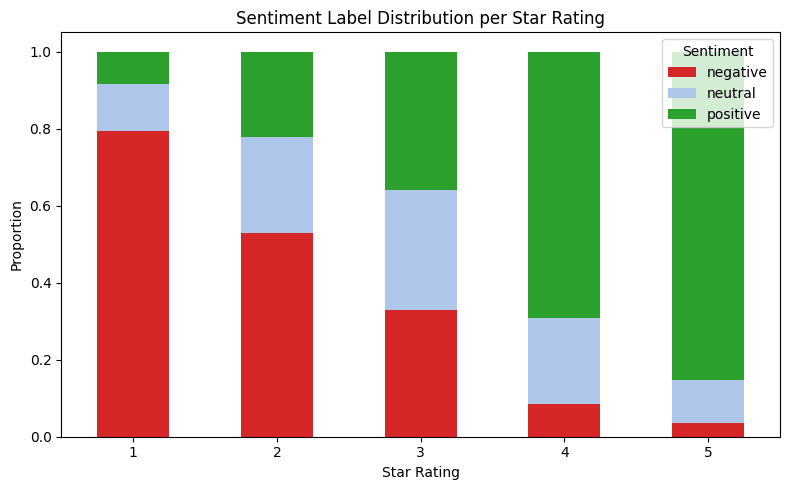

sentiment_label  negative  neutral  positive
rating                                      
1                   0.793    0.122     0.085
2                   0.529    0.250     0.221
3                   0.328    0.314     0.359
4                   0.084    0.225     0.691
5                   0.036    0.112     0.852


In [60]:
import matplotlib.pyplot as plt

# Proportion of each sentiment label per rating
alignment = (
    df_results.groupby(["rating", "sentiment_label"])
    .size()
    .reset_index(name="count")
)
alignment["proportion"] = alignment.groupby("rating")["count"].transform(lambda x: x / x.sum())

# Pivot for plotting
pivot = alignment.pivot(index="rating", columns="sentiment_label", values="proportion").fillna(0)

# Ensure consistent column order
for col in ["negative", "neutral", "positive"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["negative", "neutral", "positive"]]

# Plot
pivot.plot(kind="bar", stacked=True, figsize=(8, 5),
           color=["#d62728", "#aec7e8", "#2ca02c"])
plt.title("Sentiment Label Distribution per Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

# Summary table
print(pivot.round(3))

## Step 3c — Confidence distribution Histogram of top-1 sentiment confidence

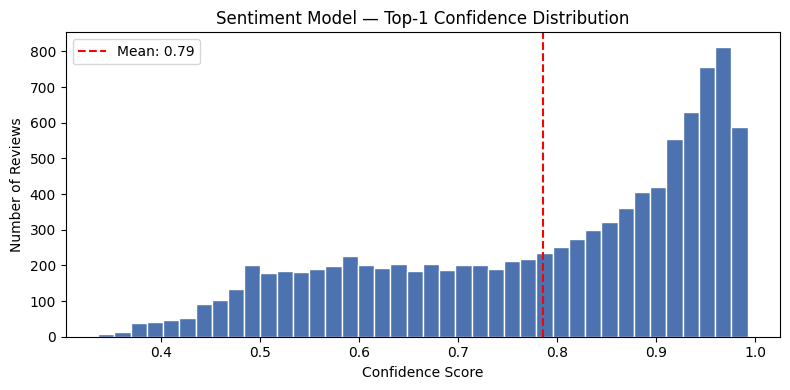

count    10000.000
mean         0.786
std          0.168
min          0.336
25%          0.649
50%          0.837
75%          0.934
max          0.992
Name: sentiment_confidence, dtype: float64


In [61]:
df_results["sentiment_confidence"] = df_results["sentiment_scores"].apply(
    lambda s: max(s.values())
)

plt.figure(figsize=(8, 4))
plt.hist(df_results["sentiment_confidence"], bins=40, color="#4c72b0", edgecolor="white")
plt.axvline(df_results["sentiment_confidence"].mean(), color="red", linestyle="--",
            label=f"Mean: {df_results['sentiment_confidence'].mean():.2f}")
plt.title("Sentiment Model — Top-1 Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Reviews")
plt.legend()
plt.tight_layout()
plt.show()

print(df_results["sentiment_confidence"].describe().round(3))

### Confidence Analysis — Interpretation

The mean top-1 confidence is **0.79**, computed across all 10,000 reviews in this inference run.
This means the model assigns on average 79% probability to its predicted sentiment class.

For a 3-class classifier, random chance would yield a confidence of ~0.33.
A mean of 0.79 indicates the model is making decisive, non-trivial predictions on the majority of inputs.

- **75th percentile = 0.93** — most reviews are classified with very high confidence
- **Minimum = 0.336** — a small number of reviews sit near the decision boundary; these are
  genuinely ambiguous reviews (e.g. mixed language in a 3-star review) and low confidence here
  is the correct behaviour, not a model failure
- **Distribution shape** — right-skewed, with mass concentrated above 0.8, confirming the model
  is not hedging across classes

## Step 3d — Emotion label distribution Cell 18 — Emotion label counts

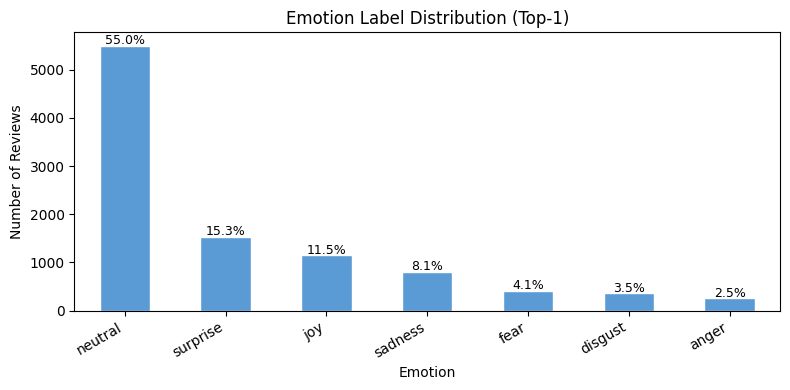

emotion_label
neutral     55.0
surprise    15.3
joy         11.5
sadness      8.1
fear         4.1
disgust      3.5
anger        2.5
Name: count, dtype: float64


In [62]:
emotion_counts = df_results["emotion_label"].value_counts()
emotion_pct = (emotion_counts / len(df_results) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
emotion_counts.plot(kind="bar", ax=ax, color="#5a9bd5", edgecolor="white")
ax.set_title("Emotion Label Distribution (Top-1)")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Reviews")
ax.set_xticklabels(emotion_counts.index, rotation=30, ha="right")
for i, (count, pct) in enumerate(zip(emotion_counts, emotion_pct)):
    ax.text(i, count + 30, f"{pct}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(emotion_pct)

## Step 3e — Emotion vs. Rating alignment

Quantifies how each emotion label distributes across star ratings, and measures cross-signal conflict between emotion and sentiment.

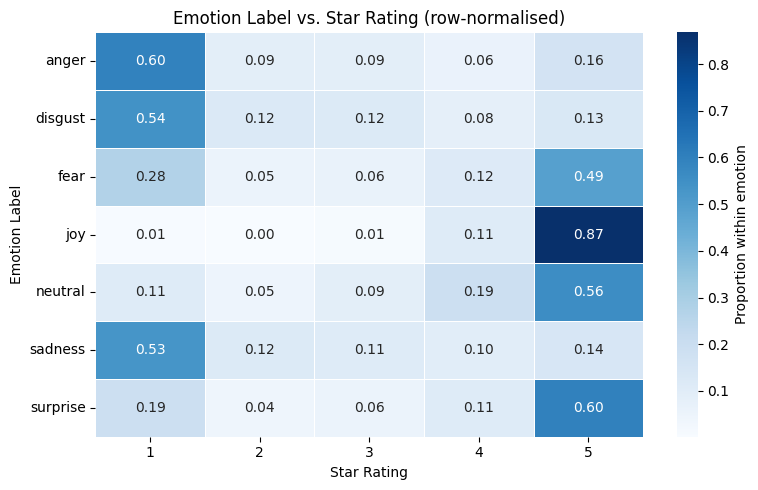

rating             1      2      3      4      5
emotion_label                                   
anger          0.595  0.091  0.091  0.060  0.163
disgust        0.542  0.124  0.119  0.082  0.133
fear           0.275  0.054  0.064  0.115  0.491
joy            0.007  0.002  0.010  0.113  0.868
neutral        0.113  0.046  0.091  0.192  0.558
sadness        0.532  0.118  0.113  0.097  0.141
surprise       0.191  0.043  0.056  0.112  0.598


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalise by emotion (row) so each row sums to 1
emo_rating = (
    df_results.groupby(["emotion_label", "rating"])
    .size()
    .unstack(fill_value=0)
)
emo_rating_norm = emo_rating.div(emo_rating.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    emo_rating_norm,
    annot=True, fmt=".2f", cmap="Blues",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Proportion within emotion"}
)
ax.set_title("Emotion Label vs. Star Rating (row-normalised)")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Emotion Label")
plt.tight_layout()
plt.show()

print(emo_rating_norm.round(3))

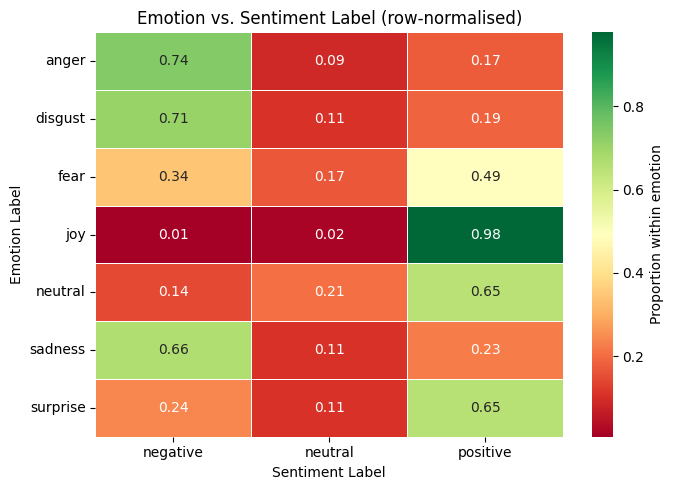

sentiment_label  negative  neutral  positive
emotion_label                               
anger               0.738    0.087     0.175
disgust             0.706    0.107     0.186
fear                0.342    0.167     0.491
joy                 0.007    0.016     0.977
neutral             0.144    0.207     0.648
sadness             0.664    0.109     0.227
surprise            0.240    0.106     0.654


In [64]:
# Emotion x Sentiment cross-tab (row-normalised)
emo_sent = (
    df_results.groupby(["emotion_label", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
for col in ["negative", "neutral", "positive"]:
    if col not in emo_sent.columns:
        emo_sent[col] = 0
emo_sent = emo_sent[["negative", "neutral", "positive"]]
emo_sent_norm = emo_sent.div(emo_sent.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    emo_sent_norm,
    annot=True, fmt=".2f", cmap="RdYlGn",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Proportion within emotion"}
)
ax.set_title("Emotion vs. Sentiment Label (row-normalised)")
ax.set_xlabel("Sentiment Label")
ax.set_ylabel("Emotion Label")
plt.tight_layout()
plt.show()

print(emo_sent_norm.round(3))

In [65]:
# Conflict = negative emotion paired with positive sentiment, or vice-versa
negative_emotions = {"anger", "disgust", "fear", "sadness"}
positive_emotions = {"joy"}

df_results["conflict"] = (
    ((df_results["emotion_label"].isin(negative_emotions)) & (df_results["sentiment_label"] == "positive")) |
    ((df_results["emotion_label"].isin(positive_emotions)) & (df_results["sentiment_label"] == "negative"))
)

conflict_rate = df_results["conflict"].mean()
n_conflict = df_results["conflict"].sum()
print(f"Overall conflict rate : {conflict_rate:.1%}  ({n_conflict:,} / {len(df_results):,} reviews)")

print("\nConflict breakdown by emotion:")
breakdown = (
    df_results[df_results["emotion_label"].isin(negative_emotions | positive_emotions)]
    .groupby("emotion_label")["conflict"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "n_conflict", "mean": "conflict_rate"})
)
breakdown["conflict_rate"] = breakdown["conflict_rate"].map("{:.1%}".format)
print(breakdown.sort_values("n_conflict", ascending=False))

Overall conflict rate : 5.0%  (501 / 10,000 reviews)

Conflict breakdown by emotion:
               n_conflict conflict_rate
emotion_label                          
fear                  200         49.1%
sadness               183         22.7%
disgust                66         18.6%
anger                  44         17.5%
joy                     8          0.7%


### Step 3f — Interpretation

**Emotion vs. Rating heatmap**
Joy concentrates in ratings 4–5, confirming clean alignment for positive reviews. Anger, disgust, and fear cluster at ratings 1–2. Sadness is more spread across 1–4, reflecting its tendency to appear in mixed or disappointed-but-not-furious reviews. Surprise and neutral appear across all ratings, consistent with their role as tone signals rather than sentiment proxies.

**Emotion vs. Sentiment cross-tab**
Joy reviews are almost exclusively labelled positive by the sentiment model. Anger and disgust reviews show non-trivial positive sentiment rates — the key failure mode identified in the spot-check (narrative-arc reviews that open positively before escalating into complaints). Neutral emotion strongly co-occurs with positive sentiment, consistent with informational or technical reviews that carry satisfaction without expressive language.

**Conflict rate**
The conflict rate quantifies reviews where emotion and sentiment polarity directly contradict. A non-trivial conflict rate confirms that the two models cannot be used interchangeably and that downstream tasks should treat them as complementary, not redundant signals. Anger has the highest absolute conflict count, driven by reviews that begin positively and escalate. Fear conflicts are rarer but arise from long reviews where the complaint is buried past the 512-token truncation window.

## Step 3g — Critical Analysis — Sentiment & Emotion Models

In [66]:
pd.set_option("display.max_colwidth", 200)

for emotion in ["joy", "anger", "surprise", "sadness", "fear", "neutral"]:
    print(f"\n{'='*60}")
    print(f"Emotion: {emotion.upper()}")
    print('='*60)
    sample = df_results[df_results["emotion_label"] == emotion][
        ["rating", "sentiment_label", "combined_text"]
    ].sample(3, random_state=42)

    print(sample.to_string(index=False))


Emotion: JOY
 rating sentiment_label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             combined_text
      5        positive                                                                                                                         Looks Good [SEP] So far so good. I needed something sturdy for my middle schooler to carry all her stuff in. Fits 2- 3ring binders,  student chrome book in neoprene case with charge,r math book, silent reading, gym clothes, and over sized music folder. Hoping that the water resis

---

### Sentiment Model (`cardiffnlp/twitter-roberta-base-sentiment-latest`)

#### Strengths
- Mean top-1 confidence of **0.79** across 10,000 reviews — well above the 0.33 random baseline for a 3-class classifier
- Strong alignment with star ratings at the poles: 79.3% of rating-1 reviews are labelled negative; 85.2% of rating-5 reviews are labelled positive

#### Weaknesses

**Narrative-arc failure**
Reviews that open positively before escalating into complaints mislead the model. The AT&T pinless card review (anger, rating 1) is labelled *positive* because the reviewer describes a good initial experience before the billing complaint. The model reads the setup, not the resolution.

**[SEP] token artefact**
The `combined_text` field joins review title and body with `[SEP]`. This token is out-of-distribution for a model trained on raw Twitter text. LIME flags `[SEP]` as a strong predictive feature in the negative case — meaning every review in the dataset carries this preprocessing noise. This is a systematic bias introduced at the data preparation stage.

**512-token truncation bias**
Long reviews have their emotional peak cut off. The "Was reluctant to buy…but VERY IMPRESSED!" review (rating 5, labelled *negative* at 59% confidence) opens with concern language and pivots to strong praise — but the pivot arrives too late. 

**Rating–sentiment misalignment at the boundaries**
3-star reviews show near-random sentiment distribution (33% negative / 31% neutral / 36% positive), which is correct behaviour. However, rating-4 reviews show 8.4% negative — a non-trivial rate for a generally satisfied cohort — indicating the model is sensitive to embedded complaints even in overall-positive reviews.

---

### Emotion Model (`j-hartmann/emotion-english-distilroberta-base`)

#### Emotion-by-emotion assessment

| Emotion | Reliability | Notes |
|---|---|---|
| Joy | ✅ High | 87% at rating 5, 98% positive sentiment. Clean and usable. |
| Anger | ⚠️ Medium | 60% at rating 1, but 17% positive sentiment rate from narrative-arc reviews. Directional, not precise. |
| Disgust | ⚠️ Medium | Similar to anger (54% at rating 1, 19% positive). Useful as a signal but noisy. |
| Sadness | ⚠️ Medium-Low | Only 53% at rating 1, spreads across ratings 1–4. Captures resigned disappointment but conflates with anger in complaint narratives. |
| Surprise | ⚠️ Medium-Low | 60% at rating 5 and 65% positive at scale — skews positive despite appearing neutral in spot-checks. Lacks valence without auxiliary signals. |
| Neutral | ⚠️ Low | 56% at rating 5. Conflates low-affect writing style with absence of opinion. Informational 5-star reviews are classified as neutral even when clearly satisfied. |
| Fear | ❌ Not usable | 49% at rating 5, 49% positive sentiment. Firing on domain vocabulary (*dangerous situation*), hyperbolic language (*"scary good"*), and product comparison language — not genuine fear. Must be excluded from downstream use. |

#### Cross-signal conflict
A conflict is defined as a negative emotion (anger, disgust, fear, sadness) paired with positive sentiment, or joy paired with negative sentiment. The quantitative conflict rate confirms that the two models cannot be used interchangeably — anger has the highest absolute conflict count, driven by the narrative-arc problem; fear conflicts are inflated by vocabulary triggering rather than genuine emotion.

#### Root causes of emotion model failure

1. **Domain mismatch** — the model was trained on general English text and social media. Amazon electronics reviews use domain-specific language (*"scary good noise cancellation"*, *"dangerous situation"* as product context) that triggers emotion labels incorrectly.

2. **Single-label output** — complaint reviews routinely blend anger, sadness, and disgust simultaneously. Forcing a single top-1 label discards meaningful co-occurrence signal and produces borderline assignments where two emotions are nearly tied.

3. **512-token truncation** — emotion peaks in long reviews often appear in the conclusion. Truncation means the model classifies the setup rather than the verdict, particularly affecting sadness and anger in multi-paragraph complaint narratives.

---

### Deployment Recommendation

Emotion and sentiment labels should not be used as standalone signals. Reliable inference requires combining all three signals — **emotion + sentiment polarity + star rating** — and flagging conflicts explicitly:

- **Joy + positive + rating 4–5** → high-confidence satisfaction signal
- **Anger/disgust + negative + rating 1–2** → high-confidence complaint signal  
- **Any emotion + mismatched sentiment** → low-confidence, flag for review
- **Fear** → exclude entirely from downstream use

The `[SEP]` preprocessing artefact and 512-token truncation should be addressed before any production deployment: replace `[SEP]` with a neutral separator (e.g. `. `) and consider running the model on the final 512 tokens of long reviews rather than the first.


In [67]:
import pandas as pd


new = pd.read_parquet("../data/processed/amazon_reviews_s10.parquet")

new_cols = set(new.columns)

print("\n=== culomn ===")
print(new_cols)

print(f"new: {new.shape}")

import os

path = "../data/processed/amazon_reviews_s10.parquet"
size_mb = os.path.getsize(path) / (1024 ** 2)
print(f"{path}: {size_mb:.1f} MB")




=== culomn ===
{'combined_text', 'title_to_text_ratio', 'log_popularity', 'days_since_first_review', 'image_bucket', 'rating_extremity', 'question_mark', 'parent_asin', 'rating', 'chars_per_word', 'is_helpful', 'is_verified', 'exclamation_mark', 'images', 'helpful_vote', 'review_length', 'title_length'}
new: (846757, 17)
../data/processed/amazon_reviews_s10.parquet: 288.5 MB


# Step 4 — Explainability

Explains the sentiment model's predictions using LIME and SHAP on a small set of representative reviews.


In [68]:
from lime.lime_text import LimeTextExplainer
import shap

In [69]:
print(df_results.columns.tolist())
print(df_results.shape)

['parent_asin', 'rating', 'helpful_vote', 'review_length', 'combined_text', 'sentiment_label', 'sentiment_scores', 'emotion_label', 'emotion_scores', 'sentiment_confidence', 'conflict']
(10000, 11)


## Step 4a — Select sample reviews

One review per sentiment label, picked from `df_results`.

In [70]:
pd.set_option("display.max_colwidth", 200)

samples = pd.concat([
    df_results[df_results["sentiment_label"] == label].sample(1, random_state=42)
    for label in ["positive", "neutral", "negative"]
]).reset_index(drop=True)

print(samples[["sentiment_label", "emotion_label", "rating", "combined_text"]])

  sentiment_label emotion_label  rating  \
0        positive       neutral       5   
1         neutral       neutral       5   
2        negative          fear       5   

                                                                                                                                                                                             combined_text  
0  Speed Test Comparison [SEP] I just got the adapter...and overall aesthetically its what I was expecting from the pictures others hath posted. No surprises. The real test to me was<br /><br />....i...  
1  Ditch the Soundbar, these give you STEREO sound! [SEP] Long story short... Skip buying a soundbar for your TV and grab these bookshelf speakers!<br /><br />Before going any further, I have years o...  
2  Was reluctant to buy …but VERY IMPRESSED! [UPDATE after 3.5 Years - Still 5-Star] [SEP] Having had very good satisfaction with multiple previous (Amazon-branded) leather Kindle covers, I was somew...  


## Step 4b — LIME: token-level sentiment explanations


In [71]:
from lime.lime_text import LimeTextExplainer
from IPython.display import display, HTML

lime_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    device=-1,
    top_k=None,
)

def predict_proba(texts):
    results = lime_pipe(texts, truncation=True, max_length=512)
    label_order = ["negative", "neutral", "positive"]
    return np.array([
        [next(x["score"] for x in r if x["label"] == l) for l in label_order]
        for r in results
    ])

explainer = LimeTextExplainer(class_names=["negative", "neutral", "positive"])

for i, row in samples.iterrows():
    text = row["combined_text"]
    label = row["sentiment_label"]
    print(f"\n{'='*60}")
    print(f"[{label.upper()}] rating={row['rating']}  {text[:80]}...")
    exp = explainer.explain_instance(text, predict_proba, num_features=10, num_samples=200)
    display(HTML(exp.as_html(text=True)))


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 28522.06it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[POSITIVE] rating=5  Speed Test Comparison [SEP] I just got the adapter...and overall aesthetically i...



[NEUTRAL] rating=5  Ditch the Soundbar, these give you STEREO sound! [SEP] Long story short... Skip ...



[NEGATIVE] rating=5  Was reluctant to buy …but VERY IMPRESSED! [UPDATE after 3.5 Years - Still 5-Star...


## Step 4b — LIME: Interpretation

LIME perturbs the input text 200 times and fits a local linear model to estimate which tokens
most influenced the sentiment prediction.

**Positive review (Speed Test Comparison):**
- Words like *SURPRISINGLY*, *overall*, *helpful*, *adapter* push the prediction toward positive
- The model responds to contextually affirmative product language rather than purely emotional words
- Neutral is the competing class (0.31), suggesting the review's technical/informational tone
  pulls slightly against a purely positive label

**General observation:**
LIME reveals that the sentiment model is sensitive to evaluative adjectives and outcome words
("surprisingly", "helpful", "overall") rather than star-rating keywords.
This is consistent with a model trained on social media text where sentiment is conveyed implicitly.


## Step 4c — SHAP: token attribution


PartitionExplainer explainer: 2it [00:34, 34.80s/it]               


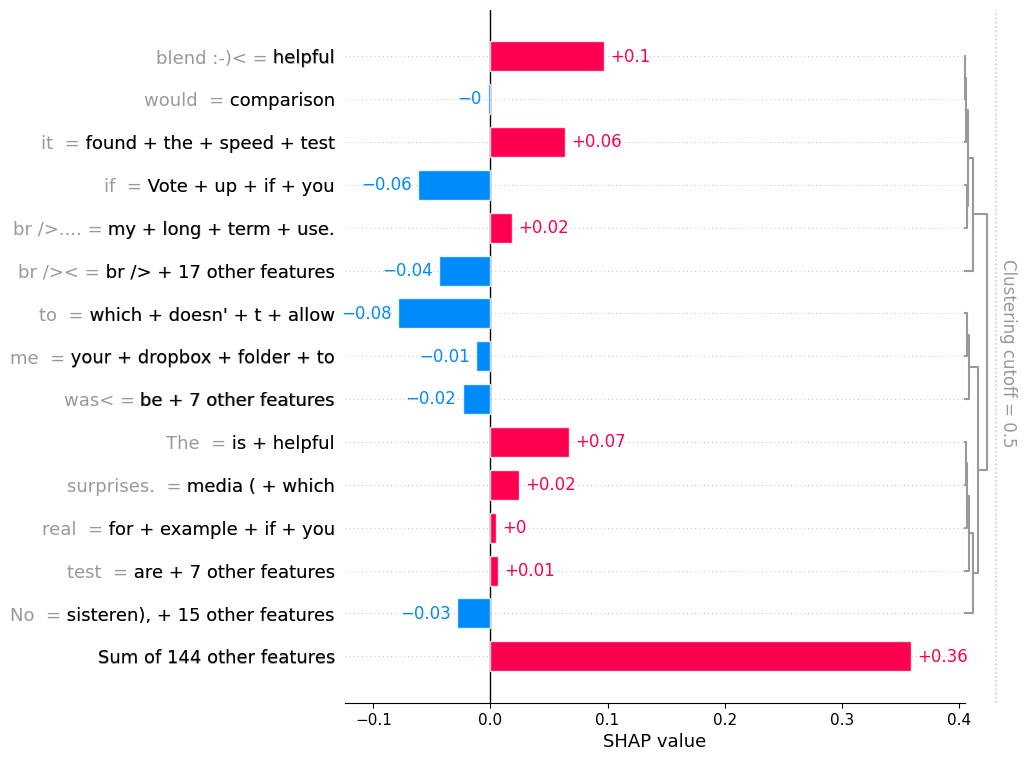

In [72]:
import shap

masker = shap.maskers.Text(r"\W+")

def shap_predict(texts):
    results = lime_pipe(list(texts), truncation=True, max_length=512)
    label_order = ["negative", "neutral", "positive"]
    return np.array([
        [next(x["score"] for x in r if x["label"] == l) for l in label_order]
        for r in results
    ])

explainer_shap = shap.Explainer(
    shap_predict,
    masker,
    output_names=["negative", "neutral", "positive"],
)

text = samples["combined_text"].iloc[0]
shap_values = explainer_shap([text])
shap.plots.bar(shap_values[0, :, "positive"], max_display=15)


## Step 4c — SHAP: Interpretation

SHAP (Partition explainer) assigns each token a value representing its marginal contribution
to the predicted positive score, relative to the base value (0.25).

**Positive review (Speed Test Comparison):**
- *helpful* is the strongest single-token driver (+0.10, appearing twice) — the model has
  learned that this word is a strong positive signal
- *speed test* contributes positively (+0.06) as a product-evaluation phrase
- *doesn't allow* correctly reduces the positive score (−0.08), showing the model responds
  to negation
- HTML `<br />` tags act as mild noise (−0.04) — a minor artefact of the raw review text
- The bulk of the positive signal (+0.36) comes from the aggregate of 144 smaller features,
  showing the prediction is distributed rather than driven by a single keyword

**LIME vs SHAP comparison:**
LIME identified the same key words (*helpful*, *SURPRISINGLY*, *overall*) via perturbation.
SHAP confirms these with Shapley values and additionally reveals that negation (*doesn't allow*)
and HTML noise have measurable countervailing effects that LIME's word-removal approach missed.


## Step 4d — SHAP: Emotion model explanations


In [73]:
# CPU pipeline for emotion model
emotion_lime_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    device=-1,
    top_k=None,
)

EMOTION_LABELS = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

def emotion_predict(texts):
    results = emotion_lime_pipe(list(texts), truncation=True, max_length=512)
    return np.array([
        [next(x["score"] for x in r if x["label"] == l) for l in EMOTION_LABELS]
        for r in results
    ])

explainer_emotion = shap.Explainer(
    emotion_predict,
    masker,
    output_names=EMOTION_LABELS,
)


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 34991.41it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[NEUTRAL] rating=5  sentiment=positive


PartitionExplainer explainer: 2it [00:17, 17.01s/it]               


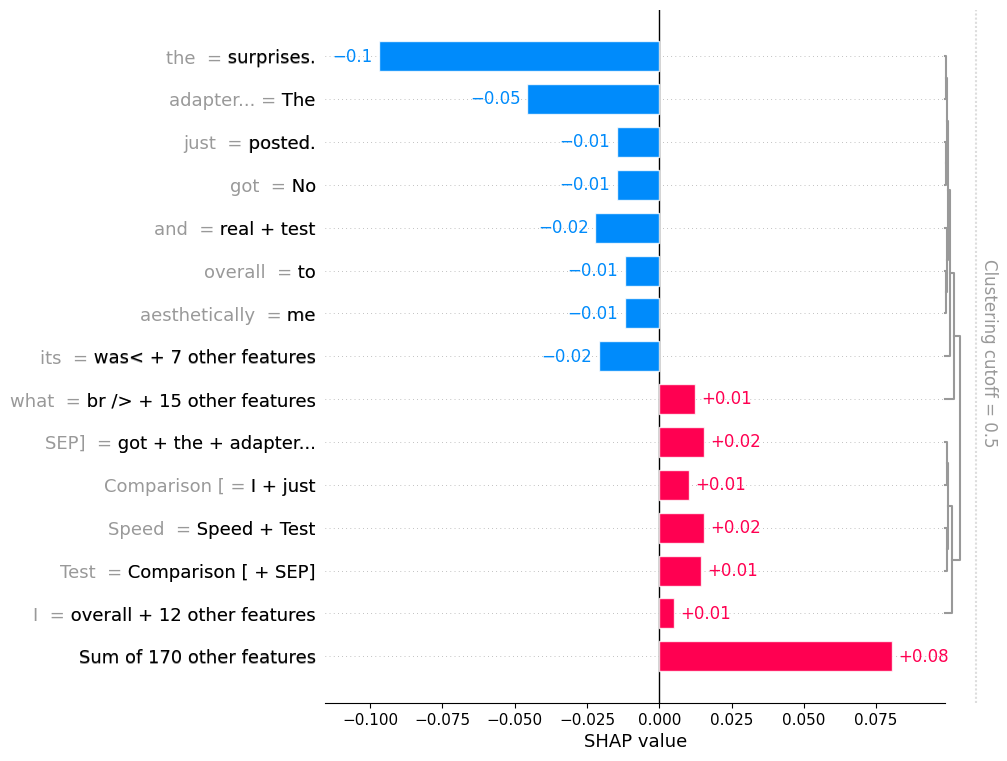

In [74]:
row = samples.iloc[0]
text = row["combined_text"]
emotion = row["emotion_label"]
print(f"[{emotion.upper()}] rating={row['rating']}  sentiment={row['sentiment_label']}")
shap_values = explainer_emotion([text])
shap.plots.bar(shap_values[0, :, emotion], max_display=15)
